In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.io as pio
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/kaggle/input/shopping-trends/shopping_trends.csv")
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [3]:
df.set_index("Customer ID" , inplace=True)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3900 entries, 1 to 3900
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   object 
 2   Item Purchased            3900 non-null   object 
 3   Category                  3900 non-null   object 
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   object 
 6   Size                      3900 non-null   object 
 7   Color                     3900 non-null   object 
 8   Season                    3900 non-null   object 
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   object 
 11  Payment Method            3900 non-null   object 
 12  Shipping Type             3900 non-null   object 
 13  Discount Applied          3900 non-null   object 
 14  Promo Code Us

In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


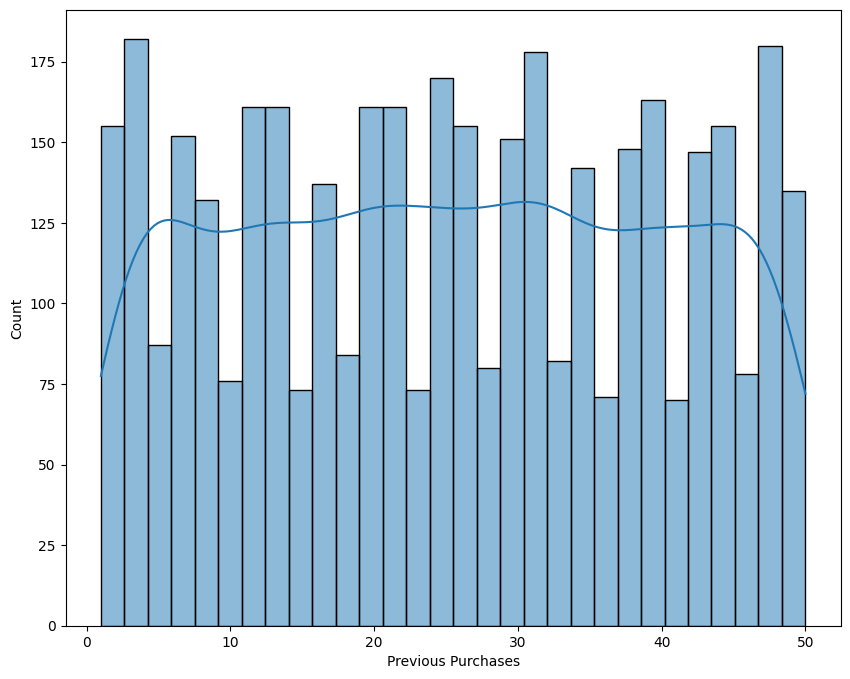

In [7]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Previous Purchases' , kde=True , bins=30)
plt.show()

In [8]:
df.describe(include='O')

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Preferred Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Credit Card,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,696,675,2223,2223,677,584


In [9]:
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
Customer ID,,,,,,,,,,,,,,,,,,
1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly


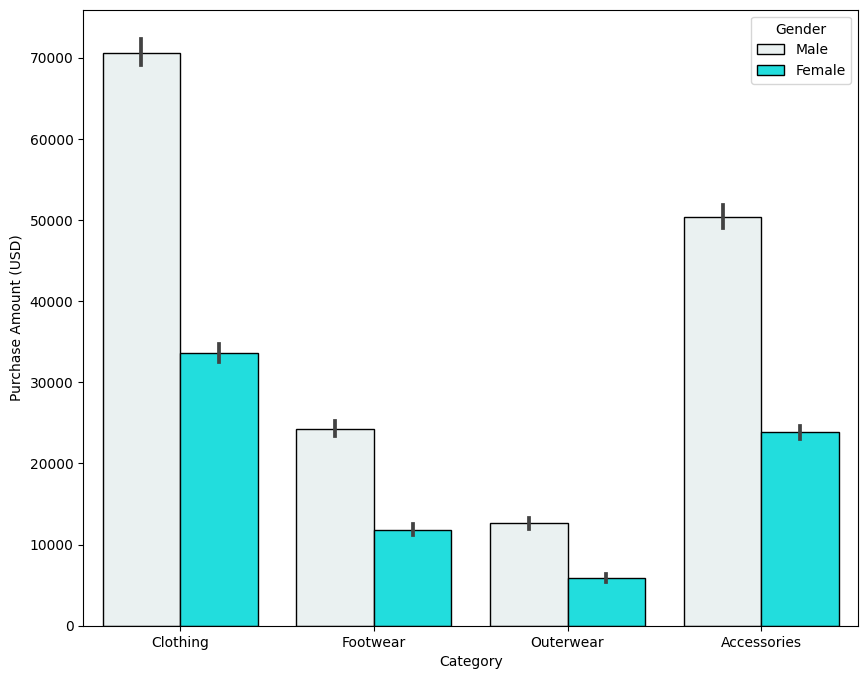

In [10]:
plt.figure(figsize=(10,8))
sns.barplot(data=df , x='Category' , y='Purchase Amount (USD)' , hue='Gender' , estimator=sum , edgecolor='black' , color='#03fcfc')
plt.show()  

In [11]:
loc = df.pivot_table(index='Location' , values='Purchase Amount (USD)' , aggfunc='mean').reset_index()
loc

,Location,Purchase Amount (USD)
0,Alabama,59.112360
1,Alaska,67.597222
2,Arizona,66.553846
3,Arkansas,61.113924
4,California,59.000000
5,Colorado,56.293333
6,Connecticut,54.179487
7,Delaware,55.325581
8,Florida,55.852941
9,Georgia,58.797468


In [12]:
loc['Location'].value_counts()

Location
Alabama           1
Pennsylvania      1
Nevada            1
New Hampshire     1
New Jersey        1
New Mexico        1
New York          1
North Carolina    1
North Dakota      1
Ohio              1
Oklahoma          1
Oregon            1
Rhode Island      1
Alaska            1
South Carolina    1
South Dakota      1
Tennessee         1
Texas             1
Utah              1
Vermont           1
Virginia          1
Washington        1
West Virginia     1
Wisconsin         1
Nebraska          1
Montana           1
Missouri          1
Mississippi       1
Arizona           1
Arkansas          1
California        1
Colorado          1
Connecticut       1
Delaware          1
Florida           1
Georgia           1
Hawaii            1
Idaho             1
Illinois          1
Indiana           1
Iowa              1
Kansas            1
Kentucky          1
Louisiana         1
Maine             1
Maryland          1
Massachusetts     1
Michigan          1
Minnesota         1
Wyoming    

In [13]:
loc['Purchase Amount (USD)'].max()

67.59722222222223

In [14]:
loc[loc['Purchase Amount (USD)'] == 67.59722222222223 ] 

,Location,Purchase Amount (USD)
1,Alaska,67.597222


In [15]:
al_loc = df[df['Location'] == 'Alaska']
al_loc

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
Customer ID,,,,,,,,,,,,,,,,,,
42,67,Male,Scarf,Accessories,39,Alaska,M,Orange,Spring,4.5,Yes,Cash,Standard,Yes,Yes,40,Venmo,Annually
53,42,Male,T-shirt,Clothing,20,Alaska,M,Green,Summer,2.6,Yes,Credit Card,Free Shipping,Yes,Yes,26,Credit Card,Weekly
250,53,Male,Handbag,Accessories,47,Alaska,S,Teal,Fall,4.2,Yes,Cash,Standard,Yes,Yes,18,Credit Card,Annually
334,39,Male,Sweater,Clothing,64,Alaska,M,Teal,Winter,4.5,Yes,Cash,Standard,Yes,Yes,15,Bank Transfer,Bi-Weekly
558,18,Male,Shirt,Clothing,60,Alaska,M,White,Spring,2.9,Yes,PayPal,Free Shipping,Yes,Yes,31,Debit Card,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3777,19,Female,Sneakers,Footwear,25,Alaska,L,Olive,Spring,4.1,No,Debit Card,Standard,No,No,10,Credit Card,Fortnightly
3791,27,Female,Handbag,Accessories,45,Alaska,XL,Beige,Summer,4.4,No,Venmo,Standard,No,No,31,Credit Card,Weekly
3837,62,Female,Skirt,Clothing,84,Alaska,M,Violet,Spring,2.5,No,Venmo,Free Shipping,No,No,38,PayPal,Fortnightly


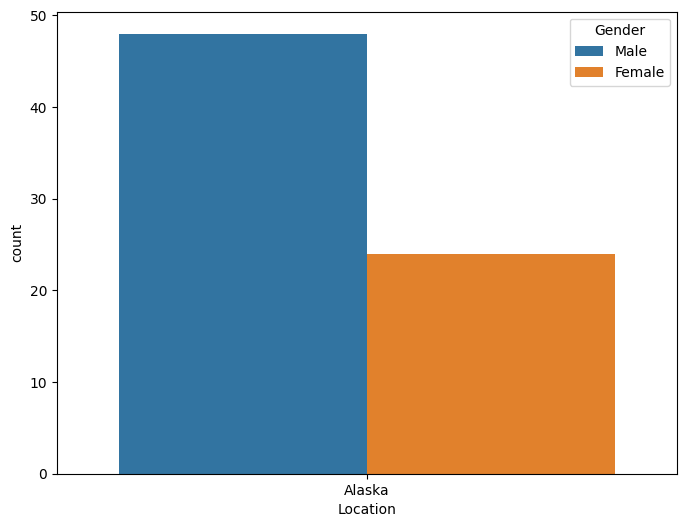

In [16]:
plt.figure(figsize=(8,6))
sns.countplot(data=al_loc , x='Location' , hue='Gender')
plt.show()

In [17]:
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
Customer ID,,,,,,,,,,,,,,,,,,
1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly


In [18]:
pio.renderers.default = 'iframe_connected'
fig = px.pie(df , names='Season' , values='Purchase Amount (USD)')
fig.update_traces(textinfo='percent+label', pull=[0.1 , 0 , 0 , 0])
fig.update_layout(legend_title_text='Brand')  
fig.update_layout(
    width=1000 , 
    height=600
)
fig.show()

In [19]:
df['Shipping Type'].value_counts()

Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64

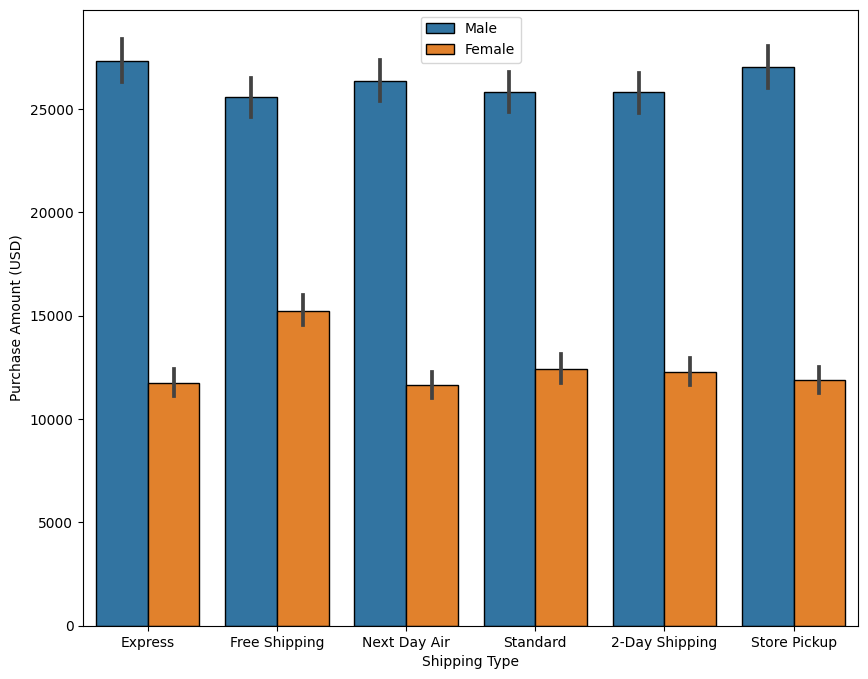

In [20]:
plt.figure(figsize=(10,8))
sns.barplot(data=df , x='Shipping Type' , y='Purchase Amount (USD)' , estimator=sum , edgecolor='black' , hue='Gender')
plt.legend(loc=0)
plt.show()

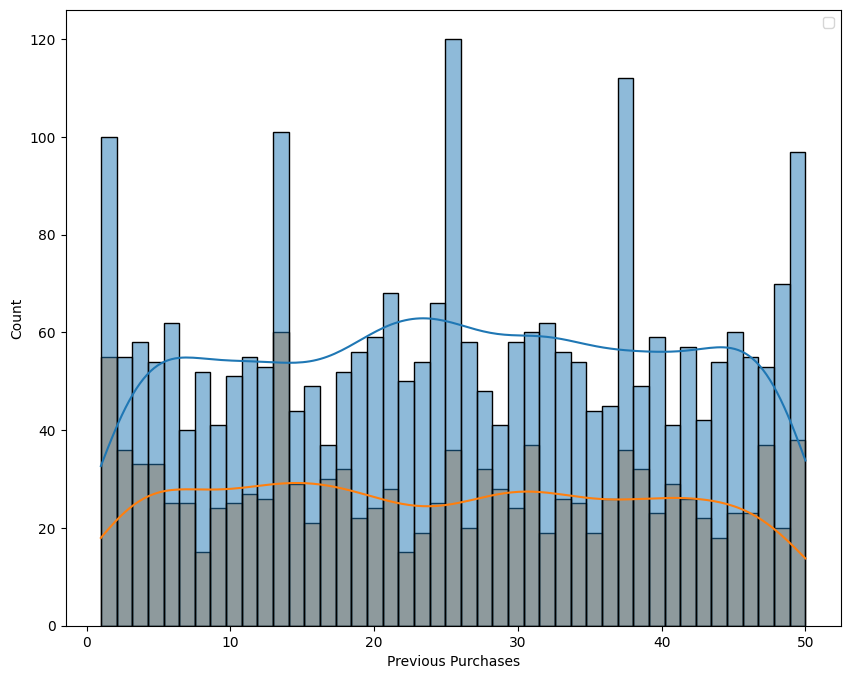

In [21]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Previous Purchases' , edgecolor='black' , kde=True , bins=45  , hue='Gender')
plt.legend(loc='upper right')
plt.show()

In [22]:
df['Frequency of Purchases'].value_counts()

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

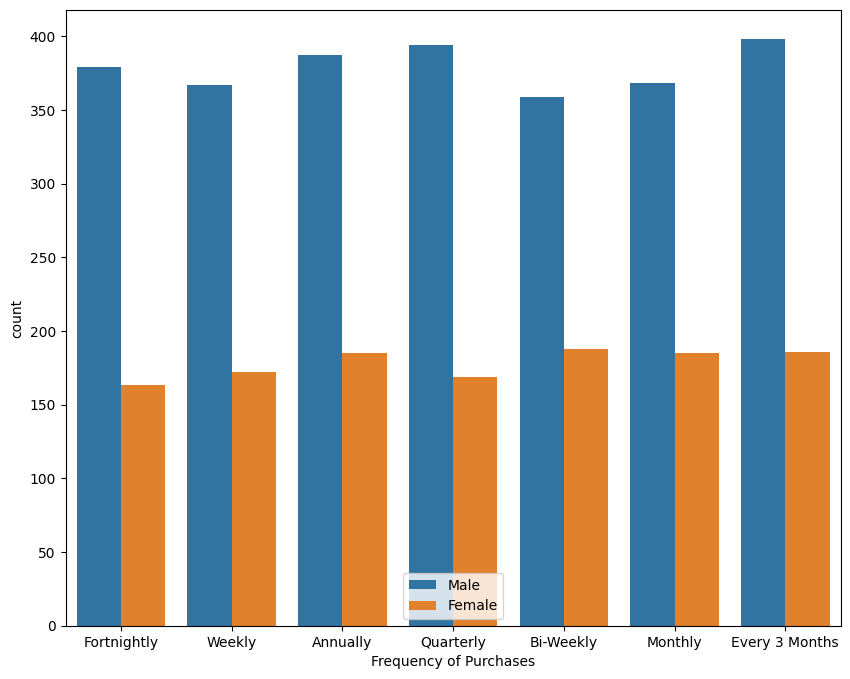

In [23]:
plt.figure(figsize=(10,8))
sns.countplot(data=df , x='Frequency of Purchases' , hue='Gender')
plt.legend(loc=8)
plt.show()

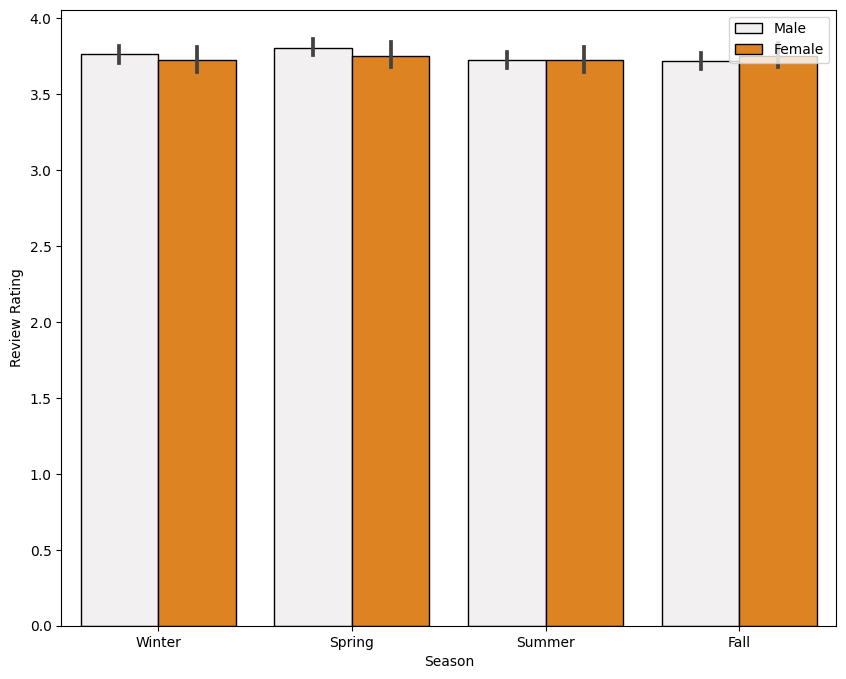

In [24]:
plt.figure(figsize=(10,8))
sns.barplot(data=df , x='Season' , y='Review Rating'  , edgecolor='black' , hue='Gender' , color='#fc8403')
plt.legend(loc='upper right')
plt.show()

In [25]:
df['Total Spent'] = df['Purchase Amount (USD)'] * (df['Previous Purchases'] + 1)

In [26]:
df['Total Spent'].agg(['min' , 'max' , 'mean'])

min       42.000000
max     5100.000000
mean    1577.641282
Name: Total Spent, dtype: float64

In [27]:
df['Payment Method'].value_counts()

Payment Method
Credit Card      696
Venmo            653
Cash             648
PayPal           638
Debit Card       633
Bank Transfer    632
Name: count, dtype: int64

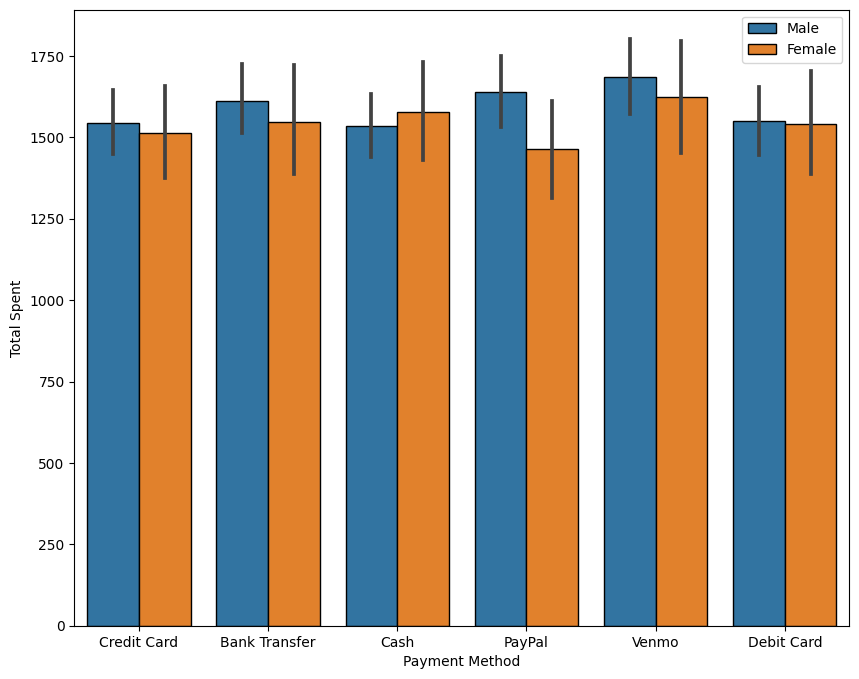

In [28]:
plt.figure(figsize=(10,8))
sns.barplot(data=df , x='Payment Method' , y='Total Spent' , edgecolor='black' , hue='Gender')
plt.legend(loc='upper right')
plt.show()

In [29]:
df.pivot_table(index='Season' , values='Total Spent' , aggfunc='mean').reset_index()

,Season,Total Spent
0,Fall,1591.133333
1,Spring,1542.081081
2,Summer,1554.796859
3,Winter,1623.147271


In [30]:
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Total Spent
Customer ID,,,,,,,,,,,,,,,,,,,
1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,795
2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,192
3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,1752
4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,4500
5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,1568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly,924
3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,2058
3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly,825


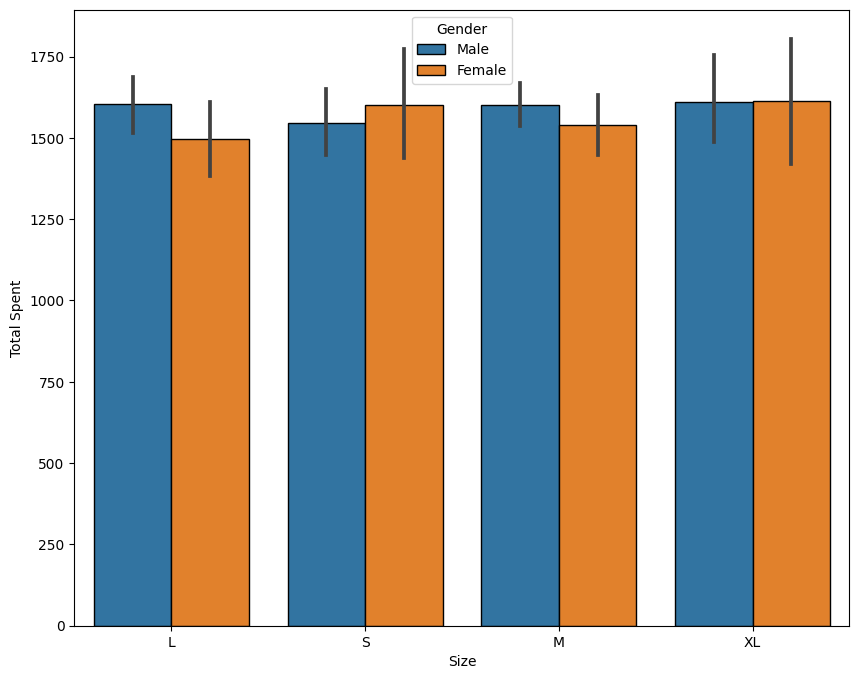

In [31]:
plt.figure(figsize=(10,8))
sns.barplot(data=df , x='Size' , y='Total Spent' , hue='Gender' , edgecolor='black')
plt.show()

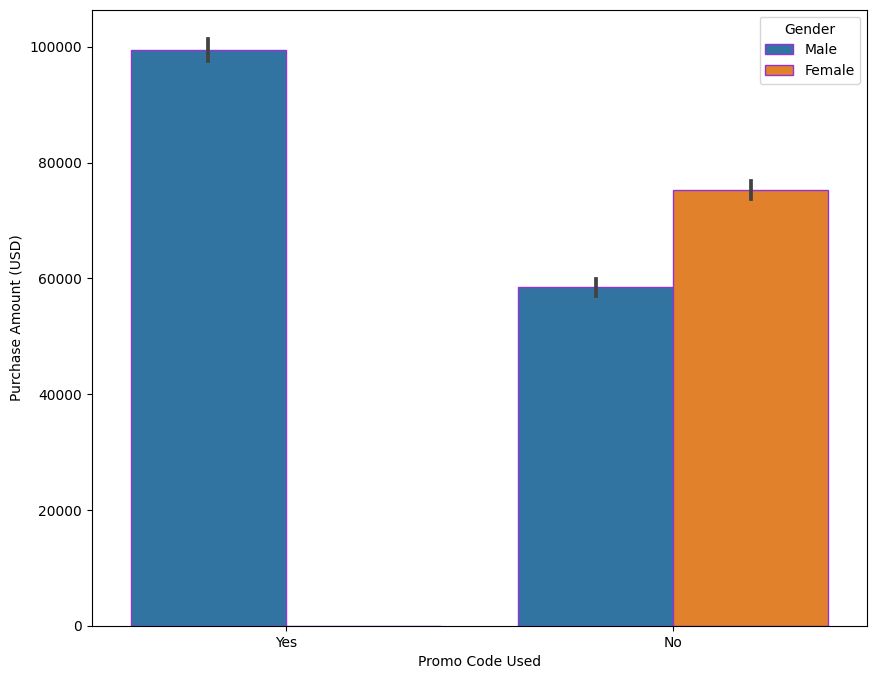

In [32]:
plt.rcParams['figure.figsize']=(10,8)
sns.barplot(data=df , x='Promo Code Used' , y='Purchase Amount (USD)' , hue='Gender' , estimator=sum , edgecolor='#9333d4')
plt.show()

In [33]:
pio.renderers.default = 'iframe_connected'
fig = px.bar(df , x='Preferred Payment Method' , y='Total Spent' , color='Gender' , text='Preferred Payment Method')
fig.update_traces(marker_color='lightblue') 
fig.update_layout(
    width=1000,
    height=600
)
fig.show()